# Using `vfp` with refnx

In this notebook, we'll run through how to use refnx with `vfp`. There's an analogous notebook for fitting a `vfp` model with refl1d [here](vfp_with_refl1d.ipynb).

To demonstrate the `vfp` we'll model some NR data taken with a Si substrate. This data is included in the `vfp` package.

Two NR contrasts were taken in a solid-liquid cell with dodecane ($\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$).

Two other contrasts were taken with the same substrate with solutions of glycerol monooleate, a surfactant, in $\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$.

In [1]:
import pathlib
import matplotlib.pyplot as plt

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

In [2]:
dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'
data_fn_dict = {
    'ddod' : 'IvsQ_71299_71300_71301.dat',
    'hdod' : 'IvsQ_71313_71314_71315.dat',
    'hdod_gmo' : 'IvsQ_71332_71333_71334.dat',
    'ddod_gmo' : 'IvsQ_71357_71358_71359.dat'
}

In [3]:
Si_dd_data = ReflectDataset(dataset_dir / data_fn_dict['ddod'])
Si_hd_data = ReflectDataset(dataset_dir / data_fn_dict['hdod'])
Si_hd_gmo_data = ReflectDataset(dataset_dir / data_fn_dict['hdod_gmo'])
Si_dd_gmo_data = ReflectDataset(dataset_dir / data_fn_dict['ddod_gmo'])

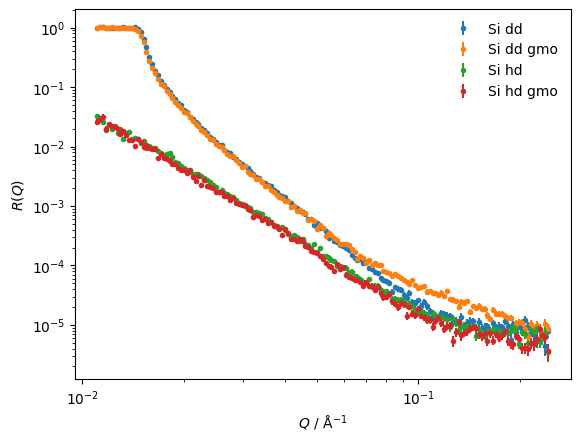

In [4]:
plt.errorbar(x=Si_dd_data.x,
             y=Si_dd_data.y,
             yerr=Si_dd_data.y_err,
             marker='.',
             linestyle='None',
             label=r'Si dd')
plt.errorbar(x=Si_dd_gmo_data.x,
             y=Si_dd_gmo_data.y,
             yerr=Si_dd_gmo_data.y_err,
             marker='.',
             linestyle='None',
             label=r'Si dd gmo')
plt.errorbar(x=Si_hd_data.x,
             y=Si_hd_data.y,
             yerr=Si_hd_data.y_err,
             marker='.',
             linestyle='None',
             label=r'Si hd')
plt.errorbar(x=Si_hd_gmo_data.x,
             y=Si_hd_gmo_data.y,
             yerr=Si_hd_gmo_data.y_err,
             marker='.',
             linestyle='None',
             label=r'Si hd gmo')
plt.legend(frameon=False)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$Q$ / $\mathrm{\AA{}}^{-1}$')
plt.ylabel(r'$R\left(Q\right)$')
plt.show()

## The model
We'll model the bare Si data with a fronting of Si, and layer of $\mathrm{SiO}_{2}$ and a solvent backing.

The SLDs of the materials will be fixed but we'll model the thickness of the $\mathrm{SiO}_{2}$ and the roughness of the interfaces between the materials.

For those contrasts with GMO, we'll model a GMO layer with a fixed SLD of $0.21 \times 10 ^{-6}~$&#8491;$^{-2}$, a varying solvation, thickness and roughness.

There will be the same interface width between $\mathrm{SiO}_{2}$ and the solvent and between $\mathrm{SiO}_{2}$ and GMO.


In [5]:
Si = SLD(2.07, name='Si')
SiO2 = SLD(3.47, name='SiO2')
gmo = SLD(0.21, name='gmo')

hdod = SLD(-0.46, name='hdod')
ddod = SLD(6.7, name='ddod')

# lets vary the ddod but not the hdod.
ddod.real.setp(vary=True, bounds=(6, 6.7))

In [6]:
# define thickness and roughness parameters.
SiO2_thick = Parameter(20, name='SiO2_thick', vary=True, bounds=(1, 30))
gmo_thick = Parameter(20, name='gmo_thick', vary=True, bounds=(1, 30))

Si_SiO2_rough = Parameter(3, name='Si_SiO2_rough', vary=True, bounds=(1, 10))
SiO2_solv_rough = Parameter(5, name='SiO2_solv_rough', vary=True, bounds=(1, 10))

SiO2_gmo_rough = Parameter(name='SiO2_gmo_rough', constraint=SiO2_solv_rough)
gmo_solv_rough = Parameter(5, name='gmo_solv_rough', vary=True, bounds=(1, 10))

gmo_vf = Parameter(1, name='gmo_vf', vary=True, bounds=(0, 1))

In [7]:
# define the SLDs of the materials in two lists for the two contrasts.
dd_nslds = [Si.real,
            SiO2.real,
            ddod.real]

hd_nslds = [Si.real,
            SiO2.real,
            hdod.real]

dd_gmo_nslds = [Si.real,
                SiO2.real,
                gmo.real * gmo_vf + ddod.real * (1-gmo_vf),
                ddod.real]

hd_gmo_nslds = [Si.real,
                SiO2.real,
                gmo.real * gmo_vf + hdod.real * (1-gmo_vf),
                hdod.real]

# define the thicknesses of the all layers, including the fronting but not the backing.
list_of_thicknesses_bare = [0, SiO2_thick]
list_of_thicknesses_gmo = [0, SiO2_thick, gmo_thick]
# define the width the of the interfaces between the materials.
list_of_roughnesses_bare = [Si_SiO2_rough, SiO2_solv_rough]
list_of_roughnesses_gmo = [Si_SiO2_rough, SiO2_gmo_rough, gmo_solv_rough]

# use the list of SLDs, thicknesses and roughnesses to define refnxVFP objects.
dd_vfp_bare = vfp.refnxVFP(nslds=dd_nslds,
                           thicknesses=list_of_thicknesses_bare,
                           roughnesses=list_of_roughnesses_bare)

hd_vfp_bare = vfp.refnxVFP(nslds=hd_nslds,
                           thicknesses=list_of_thicknesses_bare,
                           roughnesses=list_of_roughnesses_bare)

dd_vfp_gmo = vfp.refnxVFP(nslds=dd_gmo_nslds,
                           thicknesses=list_of_thicknesses_gmo,
                           roughnesses=list_of_roughnesses_gmo)

hd_vfp_gmo = vfp.refnxVFP(nslds=hd_gmo_nslds,
                           thicknesses=list_of_thicknesses_gmo,
                           roughnesses=list_of_roughnesses_gmo)

In [8]:
# see the parameters in the refnxVFP
# these contain non varying parameters.
print(dd_vfp_gmo.parameters)

________________________________________________________________________________
Parameters:       ''       
<Parameter:'refnxVFP - thicknesses - fronting', value=0  (fixed) , bounds=[-inf, inf]>
<Parameter: 'SiO2_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:  'gmo_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:'Si_SiO2_rough', value=3          , bounds=[1.0, 10.0]>
<Parameter:'SiO2_gmo_rough', value=5          , bounds=[-inf, inf], constraint=<Parameter:'SiO2_solv_rough', value=5          , bounds=[1.0, 10.0]>>
<Parameter:'gmo_solv_rough', value=5          , bounds=[1.0, 10.0]>
<Parameter:  'Si - sld'   , value=2.07  (fixed) , bounds=[-inf, inf]>
<Parameter: 'SiO2 - sld'  , value=3.47  (fixed) , bounds=[-inf, inf]>
<Parameter:  'gmo - sld'  , value=0.21  (fixed) , bounds=[-inf, inf]>
<Parameter:   'gmo_vf'    , value=1          , bounds=[0.0, 1.0]>
<Parameter: 'ddod - sld'  , value=6.7          , bounds=[6.0, 6.7]>
<Parameter:'refnxVFP - msld - fronting',

In [9]:
# the refnxVFP objects are refnx Component objects so can be placed in a refnx structure.
# place vfps between SLD objects.
dd_struc = Si | dd_vfp_bare | ddod
hd_struc = Si | hd_vfp_bare | hdod
dd_GMO_struc = Si | dd_vfp_gmo | ddod
hd_GMO_struc = Si | hd_vfp_gmo | hdod

In [10]:
# define instrument / nuisance parameters
dd_scale = Parameter(1, name='dd_scale', vary=True, bounds=(0.8, 1.2))
hd_scale = Parameter(1, name='hd_scale', vary=True, bounds=(0.8, 1.2))
dd_gmo_scale = Parameter(1, name='dd_gmo_scale', vary=True, bounds=(0.8, 1.2))
hd_gmo_scale = Parameter(1, name='hd_gmo_scale', vary=True, bounds=(0.8, 1.2))

dd_bkg = Parameter(1e-6, name='dd_bkg', vary=True, bounds=(1e-10, 1e-4))
hd_bkg = Parameter(1e-6, name='hd_bkg', vary=True, bounds=(1e-10, 1e-4))
dd_gmo_bkg = Parameter(1e-6, name='dd_gmo_bkg', vary=True, bounds=(1e-10, 1e-4))
hd_gmo_bkg = Parameter(1e-6, name='hd_gmo_bkg', vary=True, bounds=(1e-10, 1e-4))

In [11]:
dd_model = ReflectModel(structure=dd_struc, scale=dd_scale, bkg=dd_bkg, dq=2.355*3)
hd_model = ReflectModel(structure=hd_struc, scale=hd_scale, bkg=hd_bkg, dq=2.355*3)
dd_gmo_model = ReflectModel(structure=dd_GMO_struc, scale=dd_gmo_scale, bkg=dd_gmo_bkg, dq=2.355*3)
hd_gmo_model = ReflectModel(structure=hd_GMO_struc, scale=hd_gmo_scale, bkg=hd_gmo_bkg, dq=2.355*3)

dd_obj = Objective(model=dd_model, data=Si_dd_data)
hd_obj = Objective(model=hd_model, data=Si_hd_data)
dd_gmo_obj = Objective(model=dd_gmo_model, data=Si_dd_gmo_data)
hd_gmo_obj = Objective(model=hd_gmo_model, data=Si_hd_gmo_data)

# as the SLD of the GMO layer is a product of
glob_obj = GlobalObjective(objectives=[dd_obj, hd_obj, dd_gmo_obj, hd_gmo_obj])

In [12]:
# we can check all the varying parameters we are interested in are present in the glob obj.
print(glob_obj.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:  'dd_scale'   , value=1          , bounds=[0.8, 1.2]>
<Parameter:   'dd_bkg'    , value=1e-06          , bounds=[1e-10, 0.0001]>
<Parameter: 'SiO2_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:'Si_SiO2_rough', value=3          , bounds=[1.0, 10.0]>
<Parameter:'SiO2_solv_rough', value=5          , bounds=[1.0, 10.0]>
<Parameter: 'ddod - sld'  , value=6.7          , bounds=[6.0, 6.7]>
<Parameter:  'hd_scale'   , value=1          , bounds=[0.8, 1.2]>
<Parameter:   'hd_bkg'    , value=1e-06          , bounds=[1e-10, 0.0001]>
<Parameter:'dd_gmo_scale' , value=1          , bounds=[0.8, 1.2]>
<Parameter: 'dd_gmo_bkg'  , value=1e-06          , bounds=[1e-10, 0.0001]>
<Parameter:  'gmo_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:'gmo_solv_rough', value=5          , bounds=[1.0, 10.0]>
<Parameter:   'gmo_vf'    , value=1          , bounds=[0.0, 

## Optimisation
For a quick example, we'll do a differential evolution optimisation. 

We will optimise the parameter values so that the likelihood of observing the data is maximised. This is done by minimizing the negative log likelihood (hence, you should see a negative value decreasing from iteration to iteration.)

In [13]:
fitter = CurveFitter(objective=glob_obj)
fitter.fit(method='differential_evolution', workers=-1, verbose=False)

c:\Users\sandy\OneDrive\PDRA - Job 2021-2024\VFP\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -5487.429422091661
                   x: [ 1.032e+00  8.327e-06 ...  8.543e-01  5.481e-06]
                 nit: 62
                nfev: 14447
          population: [[ 1.029e+00  7.773e-06 ...  8.552e-01  5.026e-06]
                       [ 1.023e+00  8.003e-06 ...  8.773e-01  6.054e-06]
                       ...
                       [ 1.008e+00  8.543e-06 ...  8.780e-01  5.804e-06]
                       [ 1.014e+00  7.522e-06 ...  8.117e-01  5.352e-06]]
 population_energies: [-5.487e+03 -5.367e+03 ... -5.345e+03 -5.357e+03]
                 jac: [-3.140e+02  4.918e+04 ...  2.601e+02  6.260e+04]
               covar: [[ 9.561e-06  4.687e-11 ... -1.985e-06  3.765e-11]
                       [ 4.687e-11  8.206e-14 ...  3.644e-10 -2.080e-14]
                       ...
                       [-1.985e-06  3.644e-10 ...  1.108e-04 -5.803e-10]
                       [ 3.765e-11 -2

In [14]:
# see the updated model parameters after fitting.
print(glob_obj.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:  'dd_scale'   , value=1.03203 +/- 0.00309, bounds=[0.8, 1.2]>
<Parameter:   'dd_bkg'    , value=8.32712e-06 +/- 2.86e-07, bounds=[1e-10, 0.0001]>
<Parameter: 'SiO2_thick'  , value=12.4479 +/- 1.54 , bounds=[1.0, 30.0]>
<Parameter:'Si_SiO2_rough', value=5.77031 +/- 3.32 , bounds=[1.0, 10.0]>
<Parameter:'SiO2_solv_rough', value=7.87217 +/- 0.362, bounds=[1.0, 10.0]>
<Parameter: 'ddod - sld'  , value=6.5225 +/- 0.00355, bounds=[6.0, 6.7]>
<Parameter:  'hd_scale'   , value=0.913769 +/- 0.0109, bounds=[0.8, 1.2]>
<Parameter:   'hd_bkg'    , value=6.28815e-06 +/- 2.88e-07, bounds=[1e-10, 0.0001]>
<Parameter:'dd_gmo_scale' , value=0.974121 +/- 0.00314, bounds=[0.8, 1.2]>
<Parameter: 'dd_gmo_bkg'  , value=9.19167e-06 +/- 5.75e-07, bounds=[1e-10, 0.0001]>
<Parameter:  'gmo_thick'  , value=19.8955 +/- 0.967, bounds=[1.0, 30.0]>
<Parameter:'gmo_solv_rough', value=6.68577 +/- 1.

## Plot the data and model

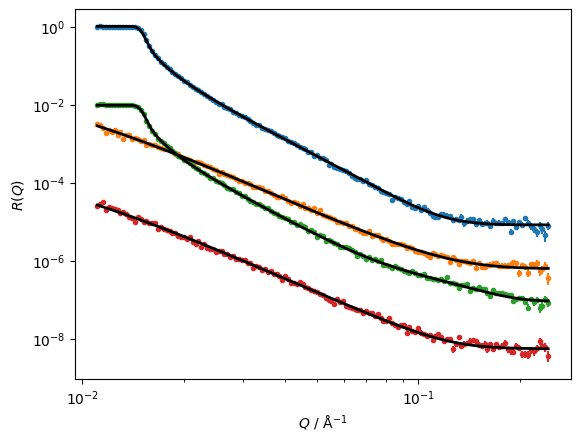

In [15]:
# data vs fit
plt.errorbar(x=Si_dd_data.x, y=Si_dd_data.y, yerr=Si_dd_data.y_err, marker='.', linestyle='None')
plt.errorbar(x=Si_hd_data.x, y=Si_hd_data.y*0.1, yerr=Si_hd_data.y_err*0.1, marker='.', linestyle='None')
plt.errorbar(x=Si_dd_gmo_data.x, y=Si_dd_gmo_data.y*0.01, yerr=Si_dd_gmo_data.y_err*0.01, marker='.', linestyle='None')
plt.errorbar(x=Si_hd_gmo_data.x, y=Si_hd_gmo_data.y*0.001, yerr=Si_hd_gmo_data.y_err*0.001, marker='.', linestyle='None')
plt.plot(glob_obj.objectives[0].data.x, glob_obj.objectives[0].generative(), zorder=5, linewidth=2, color='k')
plt.plot(glob_obj.objectives[1].data.x, glob_obj.objectives[1].generative()*0.1, zorder=6, linewidth=2, color='k')
plt.plot(glob_obj.objectives[2].data.x, glob_obj.objectives[2].generative()*0.01, zorder=7, linewidth=2, color='k')
plt.plot(glob_obj.objectives[3].data.x, glob_obj.objectives[3].generative()*0.001, zorder=8, linewidth=2, color='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$Q$ / $\mathrm{\AA{}}^{-1}$')
plt.ylabel(r'$R\left(Q\right)$')
plt.show()

## Plot the structure of the vfp

Use the `vfp.plot()` to plot the SLD, volume fraction profile and a stochastic simulation of the interface.

In the current implementation, there is no way to plot the posterior, but this will be added.

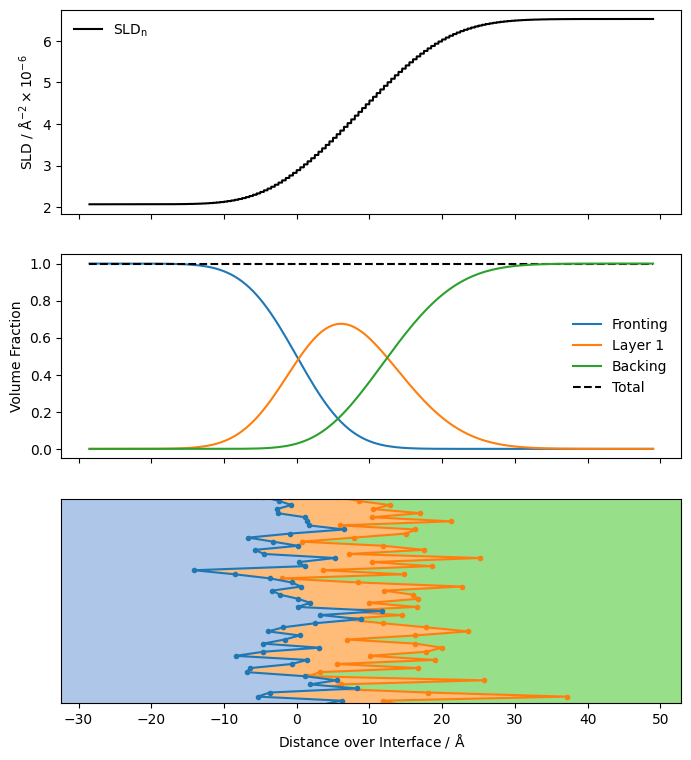

In [16]:
dd_vfp_bare.plot() # equivalent to glob_obj.objectives[0].model.structure.components[1].plot()
plt.show()

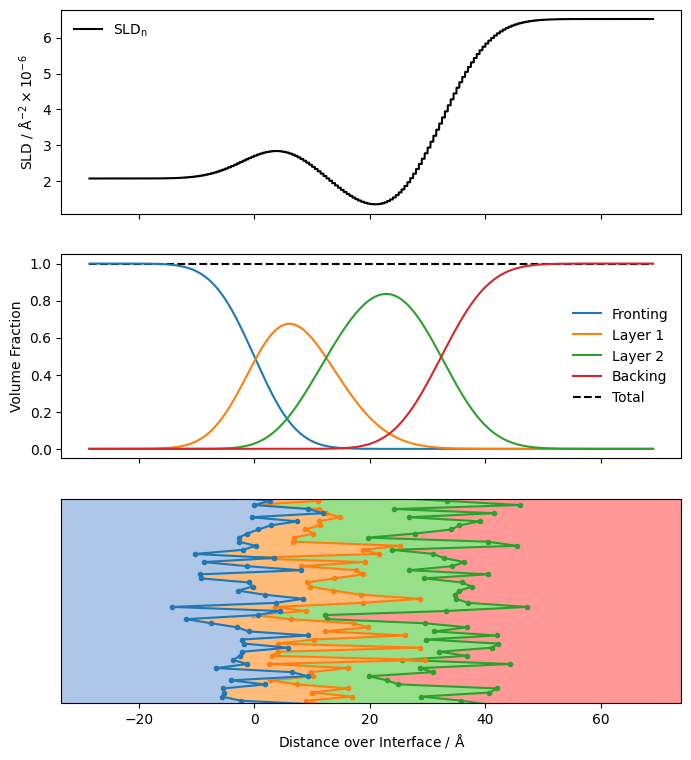

In [17]:
dd_vfp_gmo.plot() # equivalent to glob_obj.objectives[2].model.structure.components[1].plot()
plt.show()